# Notebook 5 — Supervised Multimodal Prediction with Self-Attention

**Use case:** PAM50 molecular-subtype prediction  
**Dataset:** TCGA-BRCA frozen cohort  
**Modalities:** RNA-seq, miRNA, and DNA methylation  
**Runtime target:** 15–20 minutes including discussion

## Scientific question

Notebook 1 learned a compact representation of patients.  
Notebook 2 learned shared structure between molecular views.  
Notebook 3 learned multi-view factors and modality contributions.  
Notebook 4 learned patient representations from molecular neighbourhoods.  
Now we move from representation learning to supervised prediction: can self-attention learn how RNA, miRNA and methylation interact to predict molecular subtype?

PAM50 is used as the prediction target here because this is now a **supervised** task. The test set remains held out until final evaluation, and all preprocessing is fitted only on the training partition.

## 1. Load the frozen multi-omics data

This cell reuses the three frozen patient-by-feature matrices created earlier in the workshop. No raw-data processing or new external data are introduced. Check that all molecular views have the same patient order before moving to supervised prediction.

In [1]:
# 1. Imports, reproducibility, paths, and frozen data loading
from pathlib import Path
import json
import random
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

analysis_started = time.perf_counter()
SEED = 2026
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.set_num_threads(2)

PROJECT_ROOT = Path("..")
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROCESSED_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

cohort_meta = pd.read_csv(PROCESSED_DIR / "TCGA_BRCA_cohort_metadata.tsv", sep="\t", index_col="sample_id")
rna = pd.read_csv(PROCESSED_DIR / "TCGA_BRCA_RNA_selected.tsv", sep="\t", index_col=0)
mirna = pd.read_csv(PROCESSED_DIR / "TCGA_BRCA_miRNA_selected.tsv", sep="\t", index_col=0)
meth = pd.read_csv(PROCESSED_DIR / "TCGA_BRCA_methylation_selected.tsv", sep="\t", index_col=0)

for modality_name, matrix in {"RNA": rna, "miRNA": mirna, "methylation": meth}.items():
    matrix.index = matrix.index.astype(str)
    matrix[:] = matrix.astype(np.float32)
    print(f"{modality_name}: {matrix.shape}")

assert cohort_meta.index.is_unique
assert rna.index.equals(mirna.index) and rna.index.equals(meth.index)
print(f"Frozen cohort: {len(cohort_meta)} samples; shared matrix samples: {len(rna)}")

RNA: (617, 1000)
miRNA: (617, 300)


methylation: (617, 1000)
Frozen cohort: 617 samples; shared matrix samples: 617


## 2. Select PAM50-labelled patients and make a leakage-safe split

Only patients with a known PAM50 subtype enter this supervised task. We create stratified training, validation, and held-out test partitions before scaling or fitting anything. The validation set supports early stopping; the test set is used only for final performance reporting.

In [2]:
label_column = "PAM50_subtype"
labels = cohort_meta[label_column].replace({"": np.nan, "NA": np.nan, "NaN": np.nan}).dropna()
labels = labels[labels.index.isin(rna.index)]
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(labels.astype(str))
label_names = list(label_encoder.classes_)

train_ids, test_ids = train_test_split(labels.index.to_numpy(), test_size=0.20,
                                       random_state=SEED, stratify=y)
train_ids, val_ids = train_test_split(train_ids, test_size=0.20,
                                      random_state=SEED,
                                      stratify=labels.loc[train_ids].astype(str))
print(f"PAM50-labelled patients: {len(labels)}; classes: {', '.join(label_names)}")
print(f"Leakage-safe split — train/validation/test: {len(train_ids)}/{len(val_ids)}/{len(test_ids)}")

PAM50-labelled patients: 379; classes: Basal, Her2, LumA, LumB, Normal
Leakage-safe split — train/validation/test: 242/61/76


## 3. Standardize each view using training data only

RNA, miRNA, and methylation have different numerical scales, so each view gets its own scaler. Every scaler is fit on training patients only and then applied unchanged to validation and test patients. This prevents test-set information from leaking into the learned representation.

In [3]:
modality_frames = {"RNA": rna, "miRNA": mirna, "methylation": meth}
scalers = {}
scaled = {}
for modality_name, frame in modality_frames.items():
    scaler = StandardScaler()
    scaler.fit(frame.loc[train_ids].to_numpy(dtype=np.float32))
    scalers[modality_name] = scaler
    scaled[modality_name] = {
        split_name: torch.tensor(
            scaler.transform(frame.loc[split_ids].to_numpy(dtype=np.float32)),
            dtype=torch.float32
        )
        for split_name, split_ids in {
            "train": train_ids, "validation": val_ids, "test": test_ids
        }.items()
    }
print({name: tuple(values["train"].shape) for name, values in scaled.items()})

{'RNA': (242, 1000), 'miRNA': (242, 300), 'methylation': (242, 1000)}


## 4. Represent molecular views as tokens and train the Transformer

Each omics layer is compressed into one modality token: RNA, miRNA, or methylation. A learned **CLS** token gathers their integrated information; self-attention learns relationships among these four tokens, and the final CLS representation is used for PAM50 classification. This is supervised learning: PAM50 guides the classifier, while the split and training-only scaling keep evaluation leakage-safe.

In [4]:
import copy
import torch.nn as nn
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

class AttentionBlock(nn.Module):
    def __init__(self, d_model=64, n_heads=4, ff_dim=128, dropout=0.1):
        super().__init__()
        self.attention = nn.MultiheadAttention(d_model, n_heads, dropout=dropout, batch_first=True)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.feed_forward = nn.Sequential(
            nn.Linear(d_model, ff_dim), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(ff_dim, d_model), nn.Dropout(dropout)
        )
        self.last_attention = None

    def forward(self, tokens):
        attended, weights = self.attention(
            tokens, tokens, tokens, need_weights=True, average_attn_weights=False
        )
        self.last_attention = weights.detach()
        tokens = self.norm1(tokens + attended)
        return self.norm2(tokens + self.feed_forward(tokens))

class MultimodalTransformer(nn.Module):
    def __init__(self, input_dims, n_classes, d_model=64, n_layers=2):
        super().__init__()
        self.modalities = list(input_dims)
        self.encoders = nn.ModuleDict({
            name: nn.Sequential(nn.Linear(dim, d_model), nn.LayerNorm(d_model), nn.GELU())
            for name, dim in input_dims.items()
        })
        self.cls_token = nn.Parameter(torch.zeros(1, 1, d_model))
        self.type_embedding = nn.Parameter(torch.zeros(1, len(self.modalities) + 1, d_model))
        self.layers = nn.ModuleList([AttentionBlock(d_model=d_model) for _ in range(n_layers)])
        self.classifier = nn.Sequential(nn.LayerNorm(d_model), nn.Linear(d_model, n_classes))

    def forward(self, inputs, return_attention=False):
        batch_size = next(iter(inputs.values())).shape[0]
        cls = self.cls_token.expand(batch_size, -1, -1)
        tokens = [cls] + [self.encoders[name](inputs[name]).unsqueeze(1) for name in self.modalities]
        tokens = torch.cat(tokens, dim=1) + self.type_embedding
        for layer in self.layers:
            tokens = layer(tokens)
        logits = self.classifier(tokens[:, 0])
        if return_attention:
            return logits, tokens[:, 0], self.layers[-1].last_attention
        return logits

def train_model(input_dims, train_inputs, val_inputs, y_train, y_val, max_epochs=80, patience=12):
    torch.manual_seed(SEED)
    model = MultimodalTransformer(input_dims, len(label_names))
    optimizer = torch.optim.AdamW(model.parameters(), lr=2e-3, weight_decay=1e-4)
    loss_fn = nn.CrossEntropyLoss()
    history = {"train_loss": [], "validation_loss": []}
    best_state, best_loss, best_epoch, wait = None, float("inf"), 0, 0
    for epoch in range(1, max_epochs + 1):
        model.train()
        optimizer.zero_grad()
        train_loss = loss_fn(model(train_inputs), y_train)
        train_loss.backward()
        optimizer.step()
        model.eval()
        with torch.no_grad():
            val_loss = loss_fn(model(val_inputs), y_val)
        history["train_loss"].append(float(train_loss))
        history["validation_loss"].append(float(val_loss))
        if val_loss.item() < best_loss - 1e-4:
            best_loss, best_epoch, wait = val_loss.item(), epoch, 0
            best_state = copy.deepcopy(model.state_dict())
        else:
            wait += 1
        if epoch == 1 or epoch % 10 == 0:
            print(f"epoch {epoch:02d}: train={train_loss.item():.4f}, validation={val_loss.item():.4f}")
        if wait >= patience:
            break
    model.load_state_dict(best_state)
    return model, history, best_epoch

def inputs_for(split_name, modalities):
    return {name: scaled[name][split_name] for name in modalities}

y_train = torch.tensor(label_encoder.transform(labels.loc[train_ids]), dtype=torch.long)
y_val = torch.tensor(label_encoder.transform(labels.loc[val_ids]), dtype=torch.long)
y_test = torch.tensor(label_encoder.transform(labels.loc[test_ids]), dtype=torch.long)

full_modalities = ["RNA", "miRNA", "methylation"]
input_dims = {name: scaled[name]["train"].shape[1] for name in full_modalities}
model, history, best_epoch = train_model(
    input_dims, inputs_for("train", full_modalities), inputs_for("validation", full_modalities),
    y_train, y_val
)
print(f"Best epoch: {best_epoch}; architecture: 3 modality encoders -> 4 tokens -> 2 x (4-head attention, d_model=64) -> 5-class head")

C:\Users\abhij\AppData\Local\Temp\ipykernel_31388\967235470.py:69: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:823.)
  history["train_loss"].append(float(train_loss))


epoch 01: train=1.8452, validation=0.8585


epoch 10: train=0.0930, validation=0.6674


Best epoch: 6; architecture: 3 modality encoders -> 4 tokens -> 2 x (4-head attention, d_model=64) -> 5-class head


## 5. Check training and validation behaviour

The validation curve determines early stopping without touching the held-out test set. Look for whether validation loss improves before the selected epoch rather than focusing on a long training run. This plot is a reliability check for the supervised model, not an additional biological result.

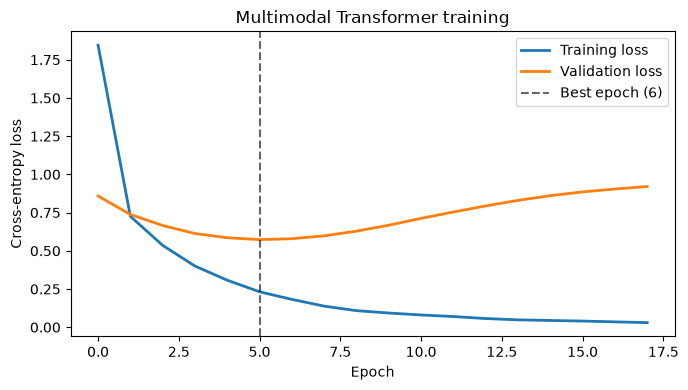

In [5]:
plt.figure(figsize=(7, 4))
plt.plot(history["train_loss"], label="Training loss", linewidth=2)
plt.plot(history["validation_loss"], label="Validation loss", linewidth=2)
plt.axvline(best_epoch - 1, color="black", linestyle="--", alpha=0.6, label=f"Best epoch ({best_epoch})")
plt.xlabel("Epoch")
plt.ylabel("Cross-entropy loss")
plt.title("Multimodal Transformer training")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "TCGA_BRCA_NB5_transformer_training.png", dpi=160)
plt.show()

## 6. Evaluate subtype predictions on the held-out test set

We now evaluate the trained full multimodal Transformer on patients it did not see during fitting or early stopping. The confusion matrix shows which PAM50 subtypes are recovered or confused. These metrics evaluate prediction on this fixed split; they do not establish a causal role for any molecular view.

{
  "accuracy": 0.8026315789473685,
  "balanced_accuracy": 0.6305263157894737,
  "macro_precision": 0.6783216783216783,
  "macro_recall": 0.6305263157894737,
  "macro_f1": 0.6412078977932636,
  "weighted_f1": 0.7802753835809033
}


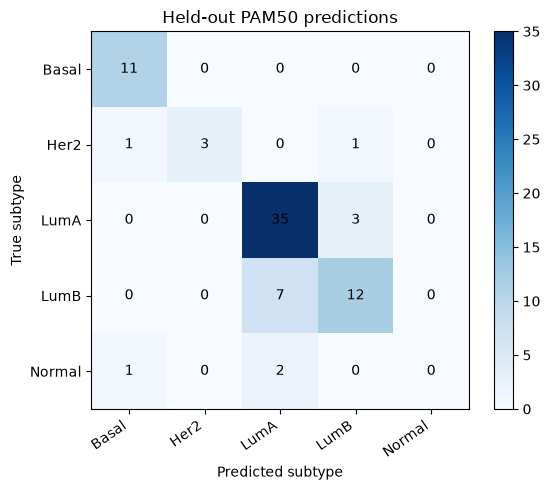

In [6]:
model.eval()
with torch.no_grad():
    logits, test_latent, attention = model(inputs_for("test", full_modalities), return_attention=True)
    test_predictions = logits.argmax(dim=1).numpy()
true_values = y_test.numpy()

metric_values = {
    "accuracy": float(accuracy_score(true_values, test_predictions)),
    "balanced_accuracy": float(balanced_accuracy_score(true_values, test_predictions)),
    "macro_precision": float(precision_score(true_values, test_predictions, average="macro", zero_division=0)),
    "macro_recall": float(recall_score(true_values, test_predictions, average="macro", zero_division=0)),
    "macro_f1": float(f1_score(true_values, test_predictions, average="macro", zero_division=0)),
    "weighted_f1": float(f1_score(true_values, test_predictions, average="weighted", zero_division=0)),
}
print(json.dumps(metric_values, indent=2))

predictions = pd.DataFrame({"sample_id": test_ids,
                            "true_subtype": label_encoder.inverse_transform(true_values),
                            "predicted_subtype": label_encoder.inverse_transform(test_predictions)})
predictions.to_csv(PROCESSED_DIR / "TCGA_BRCA_NB5_transformer_predictions.tsv", sep="\t", index=False)
with open(PROCESSED_DIR / "TCGA_BRCA_NB5_transformer_metrics.json", "w", encoding="utf-8") as handle:
    json.dump(metric_values, handle, indent=2)

confusion = confusion_matrix(true_values, test_predictions, labels=np.arange(len(label_names)))
fig, ax = plt.subplots(figsize=(6, 5))
image = ax.imshow(confusion, cmap="Blues")
fig.colorbar(image, ax=ax, fraction=.046)
ax.set_xticks(range(len(label_names)), label_names, rotation=35, ha="right")
ax.set_yticks(range(len(label_names)), label_names)
for row in range(confusion.shape[0]):
    for column in range(confusion.shape[1]):
        ax.text(column, row, confusion[row, column], ha="center", va="center")
ax.set(xlabel="Predicted subtype", ylabel="True subtype", title="Held-out PAM50 predictions")
fig.tight_layout(); fig.savefig(FIGURES_DIR / "TCGA_BRCA_NB5_transformer_confusion_matrix.png", dpi=160); plt.show()

## 7. Main teaching experiment: modality ablation

We now ask whether additional molecular layers actually contribute predictive information beyond RNA alone. Four otherwise comparable models use the exact same labelled train, validation, and test patients: RNA only; RNA plus miRNA; RNA plus methylation; and all three views. Compare macro F1 across these models rather than assuming that more modalities or a more complex architecture must improve prediction.

epoch 01: train=1.6992, validation=0.8592


epoch 10: train=0.1088, validation=0.4938


epoch 01: train=1.8324, validation=0.8923


epoch 10: train=0.0942, validation=0.8521


epoch 01: train=1.8184, validation=0.7621


epoch 10: train=0.0858, validation=0.5497


epoch 01: train=1.8452, validation=0.8585


epoch 10: train=0.0930, validation=0.6674


                    model  accuracy  balanced_accuracy  macro_f1  best_epoch
                 RNA only     0.829              0.732     0.776           7
              RNA + miRNA     0.776              0.575     0.588           5
        RNA + methylation     0.803              0.657     0.696           7
RNA + miRNA + methylation     0.803              0.631     0.641           6


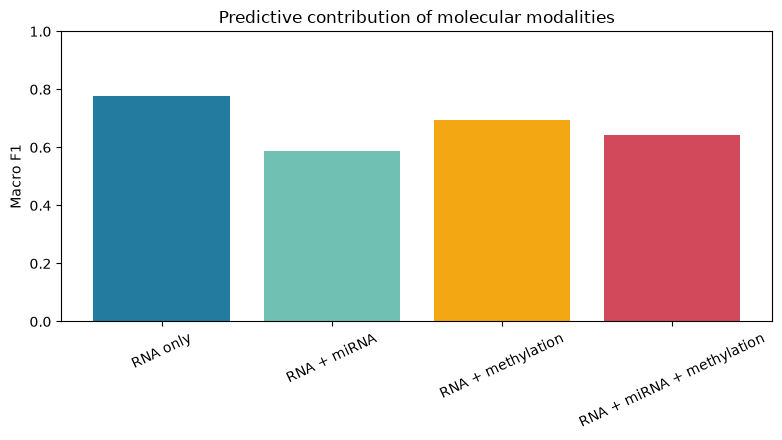

In [7]:
ablation_specs = {
    "RNA only": ["RNA"],
    "RNA + miRNA": ["RNA", "miRNA"],
    "RNA + methylation": ["RNA", "methylation"],
    "RNA + miRNA + methylation": full_modalities,
}
ablation_rows = []
for model_index, (model_name, modalities) in enumerate(ablation_specs.items()):
    random.seed(SEED + model_index)
    np.random.seed(SEED + model_index)
    ablation_model, _, ablation_epoch = train_model(
        {name: scaled[name]["train"].shape[1] for name in modalities},
        inputs_for("train", modalities), inputs_for("validation", modalities),
        y_train, y_val, max_epochs=45, patience=8
    )
    ablation_model.eval()
    with torch.no_grad():
        predictions_for_model = ablation_model(inputs_for("test", modalities)).argmax(dim=1).numpy()
    ablation_rows.append({
        "model": model_name,
        "accuracy": accuracy_score(true_values, predictions_for_model),
        "balanced_accuracy": balanced_accuracy_score(true_values, predictions_for_model),
        "macro_f1": f1_score(true_values, predictions_for_model, average="macro", zero_division=0),
        "best_epoch": ablation_epoch,
    })

ablation_results = pd.DataFrame(ablation_rows)
ablation_results.to_csv(PROCESSED_DIR / "TCGA_BRCA_NB5_modality_ablation.tsv", sep="\t", index=False)
print(ablation_results.to_string(index=False, float_format=lambda value: f"{value:.3f}"))

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(ablation_results["model"], ablation_results["macro_f1"], color=["#247ba0", "#70c1b3", "#f3a712", "#d1495b"])
ax.set_ylabel("Macro F1")
ax.set_ylim(0, 1)
ax.set_title("Predictive contribution of molecular modalities")
ax.tick_params(axis="x", rotation=25)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "TCGA_BRCA_NB5_modality_ablation.png", dpi=160)
plt.show()

## 8. Save the reported outputs

The saved prediction table, metrics, and ablation results make this fixed-split demonstration reproducible. The summary records the architecture and split sizes without adding a new experiment. The final takeaway interprets the result at the level appropriate for this workshop.

In [8]:
total_runtime_seconds = time.perf_counter() - analysis_started
metadata = {
    "random_seed": SEED, "cohort_samples": int(len(cohort_meta)), "labelled_samples": int(len(labels)),
    "train_samples": int(len(train_ids)), "validation_samples": int(len(val_ids)), "test_samples": int(len(test_ids)),
    "class_names": label_names,
    "architecture": {"tokens": ["CLS", "RNA", "miRNA", "methylation"], "transformer_layers": 2,
                     "attention_heads": 4, "d_model": 64, "classifier": [64, len(label_names)]},
    "best_epoch": int(best_epoch), "test_metrics": metric_values,
    "ablation_results": ablation_results.to_dict(orient="records"),
    "total_runtime_seconds": round(total_runtime_seconds, 3),
}
with open(PROCESSED_DIR / "TCGA_BRCA_NB5_transformer_metadata.json", "w", encoding="utf-8") as handle:
    json.dump(metadata, handle, indent=2, default=float)
print("Saved held-out predictions, full-model metrics, ablation results, and metadata.")

Saved held-out predictions, full-model metrics, ablation results, and metadata.


## FINAL TAKEAWAY

This notebook closes the progression from representation learning to biological prediction. Self-attention provides a mechanism for learning interactions between molecular views rather than simply concatenating them, and the ablation experiment tests whether additional omics layers actually improve prediction.

In the current split, RNA-only performs better than the full multimodal Transformer, demonstrating that more modalities or a more complex architecture do not automatically produce better predictions. The correct lesson is to evaluate whether each modality adds useful information for the biological question and dataset.

Across this workshop, advanced AI should be judged by the quality, interpretability and reliability of the representation it learns—not by architectural complexity alone.